# 03 · Treino do LSTM-Autoencoder

Um modelo por ativo (ADR-0003/0004). Treino com `EarlyStopping` e validação por bloco cronológico (`shuffle=False`). Inclui curvas de loss, sensibilidade de `latent_dim` e comparação com baseline (z-score).

## Setup

In [1]:
# --- Colab ---
# !git clone https://github.com/Cerne17/NeuraTrade.git
# %cd NeuraTrade
# !pip install -e .

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, model as M, train as T, baseline as B

set_seeds()
TICKERS = CONFIG['tickers']
pre = {t: pp.preprocess_ticker(df) for t, df in data.load_all().items()}
{t: o['X_train'].shape for t, o in pre.items()}

{'PETR4.SA': (2450, 30, 1),
 'VALE3.SA': (2450, 30, 1),
 'AMER3.SA': (2450, 30, 1),
 'ITUB4.SA': (2450, 30, 1)}

## Arquitetura

In [2]:
M.build_lstm_autoencoder().summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ janela (InputLayer)             │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout (Dropout)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstrucao (TimeDistributed)  │ (None, 30, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,737 (151.32 KB)

 Trainable params: 38,737 (151.32 KB)

 Non-trainable params: 0 (0.00 B)

## Treino dos 4 ativos

Pesos salvos em `models/<ticker>.keras` (regeneráveis, não versionados).

In [3]:
set_seeds()
models, histories = {}, {}
for t in TICKERS:
    mdl, hist = T.train_model(pre[t]['X_train'], ticker=t, save=True, verbose=0)
    models[t] = mdl
    histories[t] = hist.history
    ep = len(hist.history['loss'])
    print(f"{t}: parou em {ep} epocas | val_loss final={hist.history['val_loss'][-1]:.5f}")

PETR4.SA: parou em 31 epocas | val_loss final=0.00352
VALE3.SA: parou em 15 epocas | val_loss final=0.00430
AMER3.SA: parou em 60 epocas | val_loss final=0.00354
ITUB4.SA: parou em 17 epocas | val_loss final=0.00440


## Curvas de loss (treino vs. validação)

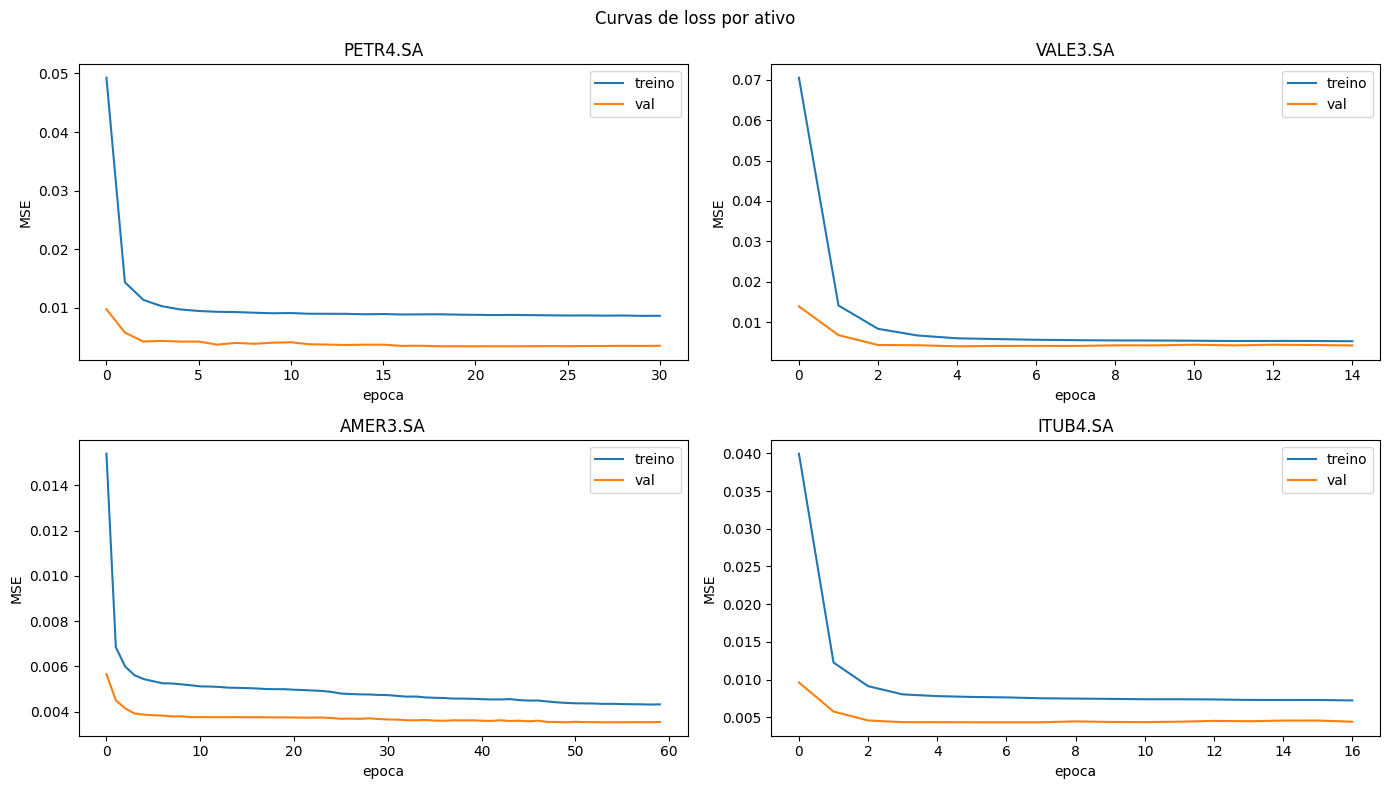

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, t in zip(axes.ravel(), TICKERS):
    h = histories[t]
    ax.plot(h['loss'], label='treino')
    ax.plot(h['val_loss'], label='val')
    ax.set_title(t); ax.set_xlabel('epoca'); ax.set_ylabel('MSE'); ax.legend()
fig.suptitle('Curvas de loss por ativo')
fig.tight_layout(); plt.show()

## Reconstrução de dias normais

Sobre o treino (normalidade), o erro de reconstrução deve ser baixo e concentrado. A cauda direita já sinaliza candidatos a anomalia (limiar formal em M4).

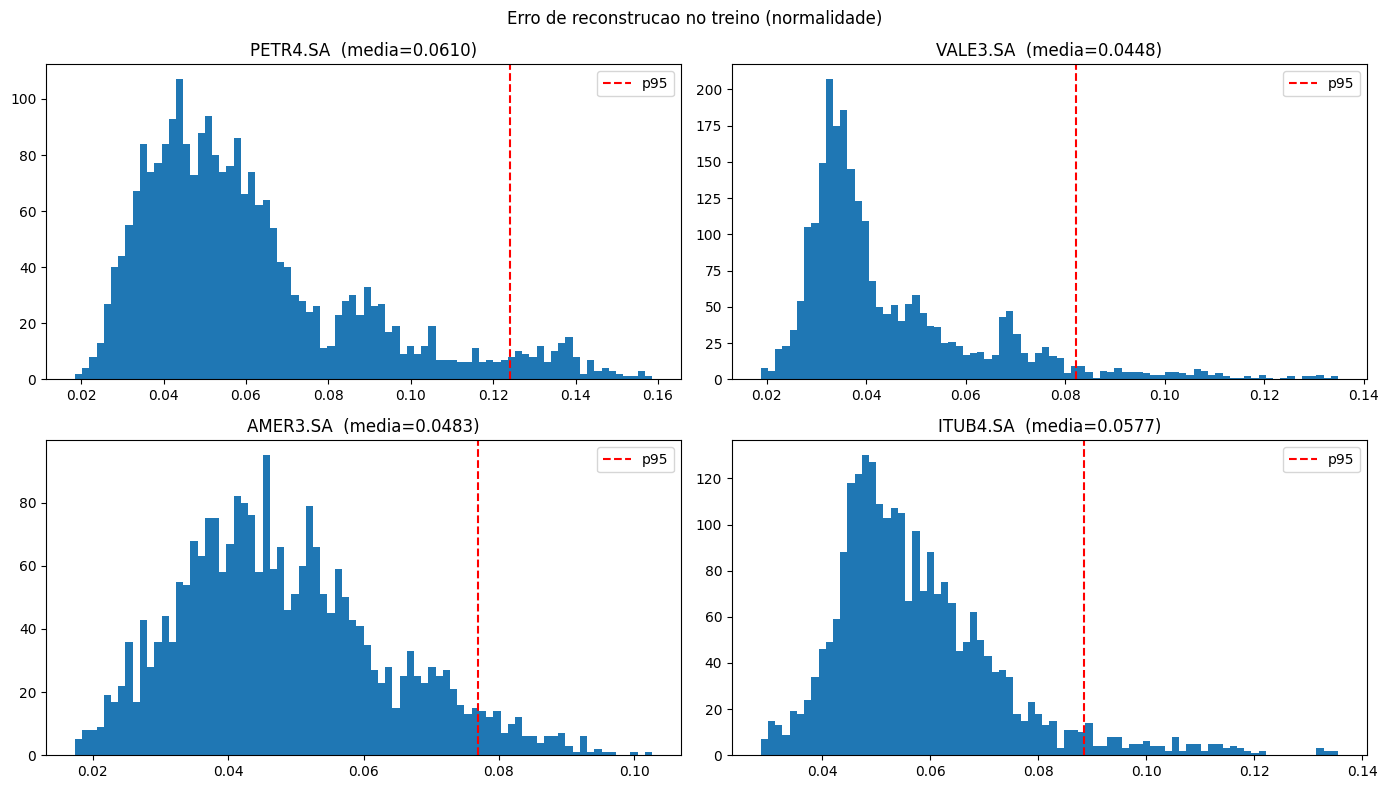

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, t in zip(axes.ravel(), TICKERS):
    err = T.reconstruction_error(models[t], pre[t]['X_train'])
    ax.hist(err, bins=80)
    ax.axvline(np.percentile(err, 95), color='red', ls='--', label='p95')
    ax.set_title(f'{t}  (media={err.mean():.4f})'); ax.legend()
fig.suptitle('Erro de reconstrucao no treino (normalidade)')
fig.tight_layout(); plt.show()

## Sensibilidade de `latent_dim` (ADR-0003)

`latent_dim` foi uma decisão de projeto a calibrar. Comparação rápida do `val_loss` final em um ativo, para 8/16/32.

In [6]:
t0 = TICKERS[0]
for ld in [8, 16, 32]:
    set_seeds()
    m = M.build_lstm_autoencoder(latent_dim=ld)
    h = m.fit(pre[t0]['X_train'], pre[t0]['X_train'],
              epochs=CONFIG['train']['epochs'], batch_size=CONFIG['train']['batch_size'],
              validation_split=CONFIG['train']['validation_split'], shuffle=False,
              callbacks=[__import__('tensorflow').keras.callbacks.EarlyStopping(
                  monitor='val_loss', patience=CONFIG['train']['early_stopping_patience'],
                  restore_best_weights=True)], verbose=0)
    print(f'latent_dim={ld:2d}: val_loss={min(h.history["val_loss"]):.5f} ({len(h.history["loss"])} epocas)')

latent_dim= 8: val_loss=0.00342 (27 epocas)
latent_dim=16: val_loss=0.00343 (31 epocas)
latent_dim=32: val_loss=0.00342 (31 epocas)


## Baseline: z-score em janela móvel (issue #14)

Chão de comparação sem aprendizado. Verifica-se se o baseline também acende nas anomalias reais — e o LSTM-AE precisa superá-lo na avaliação quantitativa (M5).

In [7]:
amer = data.load_ticker('AMER3.SA')
r = pp.log_returns(amer)
z = B.rolling_zscore(r)
print('z-score nas datas-chave do AMER3:')
for d in ['2023-01-12', '2024-11-14']:
    print(f'  {d}: |z|={z.loc[d]:.2f}')
print('\ntop-5 |z|:'); print(z.dropna().nlargest(5))

z-score nas datas-chave do AMER3:
  2023-01-12: |z|=13.95
  2024-11-14: |z|=9.74

top-5 |z|:
Date
2023-01-12    13.949476
2024-08-15    11.042044
2024-11-14     9.738170
2014-01-27     7.189338
2024-07-09     6.826186
Name: zscore, dtype: float64


## Conclusões

- Os quatro modelos treinam de forma estável, com `val_loss` decrescente e parada antecipada (EarlyStopping), sem sinais de overfitting nas curvas.
- O erro de reconstrução no treino é concentrado, com cauda direita — base para o threshold do M4.
- A sensibilidade de `latent_dim` orienta a escolha do gargalo (registrar resultado no ADR-0003 se divergir de 16).
- O baseline z-score acende nas anomalias reais, mas será confrontado quantitativamente com o LSTM-AE em M5.
- Próximo (M4): formalizar thresholds estático (p95) e dinâmico (causal) sobre o erro.